In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv as J_n, yv as Y_n, riccati_jn as Psi_n, riccati_yn as Chi_n
from matplotlib import colors
from astropy import units as u
from astropy.constants import c
plt.style.use('../../alex_style.mplstyle')

In [112]:
import miepython as mie
from miepython import core
import pandas as pd

In [113]:
def GHz_to_x(f):
    return (np.pi*d * f/c).decompose().value

def GHz_to_lamb(f):
    return (c / f)

d = 400*u.um    #bubble diameter
n = 1.0003      #index of refraction
n_env = 1.54    #index of the matrix
theta = np.linspace(0, 180, 181)
mu = np.cos(theta / 180 * np.pi)

# By Hand...

In [114]:
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn

# ---- Functions ----
def psi(n, z):
    return z * spherical_jn(n, z)

def xi(n, z):
    return z * (spherical_jn(n, z) + 1j * spherical_yn(n, z))

def dpsi(n, z):
    return spherical_jn(n, z) + z * spherical_jn(n, z, derivative=True)

def dxi(n, z):
    return spherical_jn(n, z) + 1j*spherical_yn(n, z) + z*(spherical_jn(n, z, derivative=True) + 1j*spherical_yn(n, z, derivative=True))

# ---- Compute angular functions pi_n, tau_n ----
def angular_functions(mu, Nmax):
    pi = np.zeros((Nmax+1, len(mu)))
    tau = np.zeros_like(pi)
    pi[1] = 1.0  # pi_1 = 1
    for n in range(2, Nmax+1):
        pi[n] = ((2*n-1)/(n-1))*mu*pi[n-1] - (n/(n-1))*pi[n-2]
    for n in range(1, Nmax+1):
        tau[n] = n*mu*pi[n] - (n+1)*pi[n-1]
    return pi, tau

In [ ]:
f = 150       # frequency [GHz]
d = 400*u.um  #bubble diameter
n_p = 1.0003  #index of refraction
n_m = 1.54    #index of the matrix

# theta = np.linspace(-180, 180, 361)
# mu = np.cos(theta / 180 * np.pi)

lamb = GHz_to_lamb(f*u.GHz).to(u.um).value
Ipar, Iper = mie.intensities(n_p, d.to(u.um).value, lamb, mu, n_env=n_m)
I = (Ipar + Iper) / 2

# Relative index and size parameter
lam0 = GHz_to_lamb(f*u.GHz)
m = n_p / n_m
k = 2*np.pi * n_m / lam0   # wavenumber in medium
x = (k*d/2).to(1)            # size parameter

## For an array of frequencies...

In [116]:
fs = np.array((30, 40, 90, 150, 220, 280))

rows = []

for f in fs:
    lam0 = GHz_to_lamb(f*u.GHz).to(u.um)
    print(lam0)
    k = 2*np.pi * n_m / lam0   # wavenumber in medium
    x = (k*d/2).to(1)            # size parameter

    Nmax = int(np.round(x + 4*x**(1/3) + 2)) ## from Wiscombe, 1980
    a_n, b_n = [], []

    for n in range(1, Nmax+1):
        mx = m*x
        an = (m*psi(n, mx)*dpsi(n, x) - psi(n, x)*dpsi(n, mx)) / \
            (m*psi(n, mx)*dxi(n, x) - xi(n, x)*dpsi(n, mx))
        bn = (psi(n, mx)*dpsi(n, x) - m*psi(n, x)*dpsi(n, mx)) / \
            (psi(n, mx)*dxi(n, x) - m*xi(n, x)*dpsi(n, mx))
        a_n.append(an)
        b_n.append(bn)

    a_n, b_n = np.array(a_n), np.array(b_n)

    pi, tau = angular_functions(mu, Nmax)

    # ---- Compute S1 and S2 ----
    S1 = np.zeros(len(mu), dtype=complex)
    S2 = np.zeros(len(mu), dtype=complex)

    for n in range(1, Nmax+1):
        coeff = (2*n+1)/(n*(n+1))
        S1 += coeff * (a_n[n-1]*pi[n] + b_n[n-1]*tau[n])
        S2 += coeff * (a_n[n-1]*tau[n] + b_n[n-1]*pi[n])

    # ---- Phase function ----
    intensity = (np.abs(S1)**2 + np.abs(S2)**2).real

    A = (2*np.pi * np.trapz(intensity*np.sin(theta), theta))
    phase_function = intensity/A
    S1 = 2*np.abs(S1)**2/A
    S2 = 2*np.abs(S2)**2/A
    rows.append({
        "freq_GHz": f,
        "lamb_um": lam0,
        "I": phase_function,
        "Iper": S1,
        "Ipar": S2,
    })

df = pd.DataFrame(rows).set_index("freq_GHz")

9993.081933333333 um
7494.81145 um
3331.0273111111114 um
1998.6163866666668 um
1362.692990909091 um
1070.6873500000002 um


C:\Users\Shreya Sutariya\AppData\Local\Temp\ipykernel_17552\846670075.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A = (2*np.pi * np.trapz(intensity*np.sin(theta), theta))


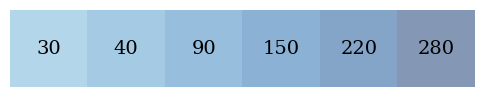

In [117]:
#color the dictionary
cmap = plt.get_cmap('Blues')
cmap_array = cmap(np.linspace(0, 1, 256))
cmap_array = cmap_array[len(cmap_array) // 2:]
entries = len(fs)
values = np.linspace(0, 1, entries)  # Generate values from 0 to 1 for the colormap

indices = np.linspace(0, len(cmap_array)-1, entries).astype(int)

# Sample from the cmap_array using the indices
colors1 = cmap_array[indices]  # skip first if you want to avoid lightest color

# Display for visualization
large_font = 14  # font size for labels
plt.figure(figsize=(entries, 1))
plt.imshow([colors1], aspect='auto', alpha=0.5)

for i in range(entries):  # one less because we skipped first color
    plt.annotate(fs[i], (i, 0), color='k', fontsize=large_font, ha='center', va='center')

plt.gca().set_axis_off()

16.754522816956555


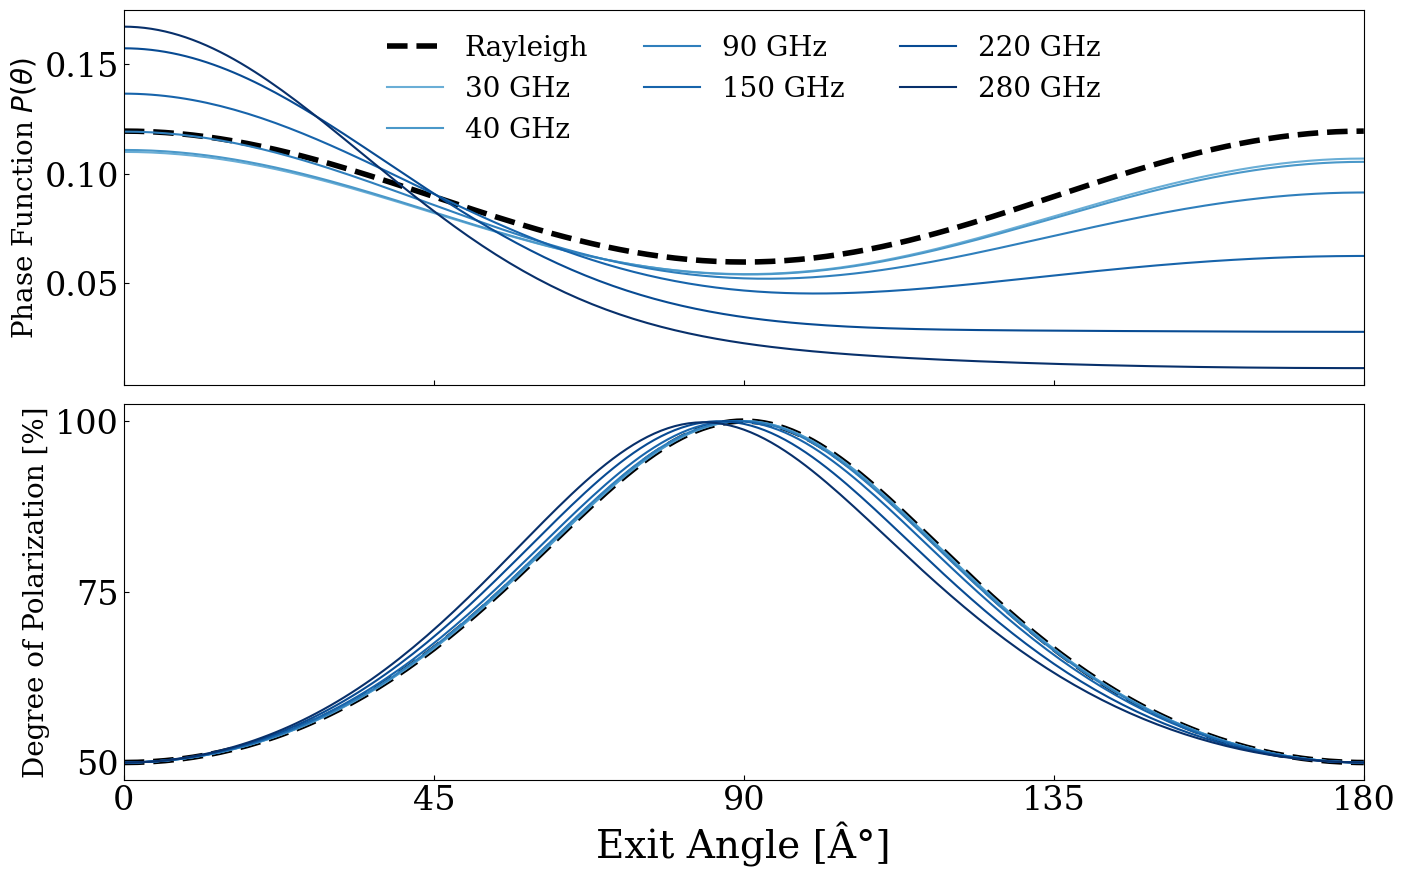

In [118]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(16,10), sharex=True)

# Manually adding rayleigh
I_ray = 1+np.cos(theta/180*np.pi)**2

theta_norm = theta[(theta >= 0) & (theta <= 180)]
I_ray_norm = I_ray[(theta >= 0) & (theta <= 180)]

A = 2*np.pi*np.trapezoid(I_ray_norm*np.sin(theta_norm/180*np.pi), theta_norm/180*np.pi)
print(A)
I_ray = I_ray / A

ax0.plot(theta, I_ray, label='Rayleigh', color='k', ls='--', lw=4)
ax1.plot(theta, 100/(1+np.cos(theta/180*np.pi)**2), label='Rayleigh', color='k', ls='--', lw=4)

for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    I = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax0.plot(theta, I, label=f"{f} GHz", color=colors1[i])
    ax1.plot(theta, 100*Iper/(Iper+Ipar), color=colors1[i])

    # plt.text(0, 0, f"Average Angle\nUnpolarized: {Iunp_avg:.2f}\nParallel: {Ipar_avg:.2f}\nPerpendicular: {Iper_avg:.2f}", fontsize=32, ha='center')

ax0.legend(loc='upper center', ncol=3, frameon=False)
ax0.set_ylabel(r'Phase Function $P(\theta)$', fontsize=20)
ax1.set_ylabel('Degree of Polarization [%]', fontsize=20)
plt.xlabel("Exit Angle [Â°]")
plt.xlim(0, 180)
plt.xticks([0, 45, 90, 135, 180])
ax1.set_yticks([50, 75, 100])

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=3)

plt.subplots_adjust(hspace=0.05)
# plt.yscale('log')
plt.show()

# With `miepython`

In [119]:
theta_site = 12.47
mu_site    = np.cos(theta_site / 180 * np.pi)

lamb_90 = GHz_to_lamb(90*u.GHz).to(u.um).value
Ipar, Iper = mie.intensities(n_p, d.to(u.um).value, lamb_90, mu_site, n_env=n_m)
I_site = (Ipar + Iper)/2

print(I_site)

[0.13211467]


In [120]:
data = {}

theta = np.linspace(0, 180, 181)
mu = np.cos(theta / 180 * np.pi)

fs = np.array((30, 40, 90, 150, 220, 280))
rows = []

for f in fs:
    lamb = GHz_to_lamb(f*u.GHz).to(u.um).value
    Ipar, Iper = mie.intensities(n_p, d.to(u.um).value, lamb, mu, n_env=n_m)
    I = (Ipar + Iper) / 2

    norm_par = -2 * np.pi * np.trapezoid(Ipar, mu)
    norm_per = -2 * np.pi * np.trapezoid(Iper, mu)
    
    Ipar_norm = Ipar / norm_par
    Iper_norm = Iper / norm_per

    if f == 90:
        I_90 = I
    elif f == 150:
        I_150 = I

    rows.append({
        "freq_GHz": int(f),
        "lamb_nm": lamb,
        "I": I,
        "Iper": Iper,
        "Ipar": Ipar,
        "Iper_norm": Iper_norm,
        "Ipar_norm": Ipar_norm,

    })

df = pd.DataFrame(rows).set_index("freq_GHz")

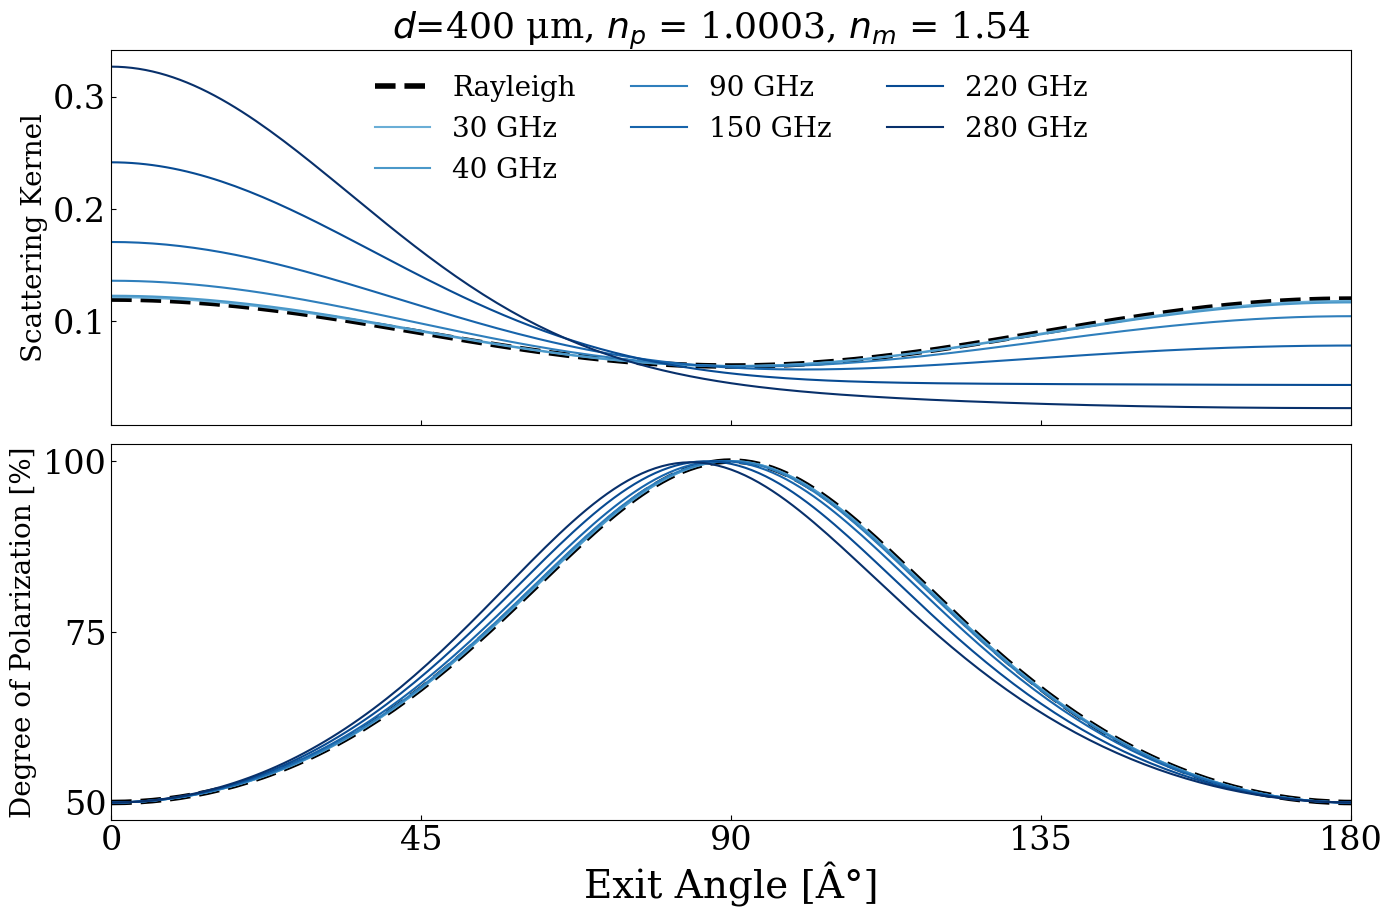

In [121]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(16,10), sharex=True)

ax0.plot(theta, I_ray, label='Rayleigh', color='k', ls='--', lw=4)
ax1.plot(theta, 100/(1+np.cos(theta/180*np.pi)**2), label='Rayleigh', color='k', ls='--', lw=4)

for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    I = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax0.plot(theta, I, label=f"{f} GHz", color=colors1[i])
    ax1.plot(theta, 100*Iper/(Iper+Ipar), label='Perpendicular' if i==0 else None, color=colors1[i])
    # ax0.scatter(theta_site, I_site, s=40)
    # ax1.plot(theta, Ipar, label='Parallel' if i==0 else None, color=colors1[i])

    # plt.text(0, 0, f"Average Angle\nUnpolarized: {Iunp_avg:.2f}\nParallel: {Ipar_avg:.2f}\nPerpendicular: {Iper_avg:.2f}", fontsize=32, ha='center')

ax0.legend(loc='upper center', ncol=3, frameon=False)
ax0.set_ylabel(r'Scattering Kernel', fontsize=20)
ax1.set_ylabel('Degree of Polarization [%]', fontsize=20)
plt.xlabel("Exit Angle [Â°]")
plt.xlim(0, 180)
plt.xticks([0, 45, 90, 135, 180])
ax1.set_yticks([50, 75, 100])

plt.suptitle(r"$d$=400 μm, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=3)

plt.subplots_adjust(hspace=0.05)
# plt.yscale('log')
plt.gcf().set_facecolor('none')
plt.show()

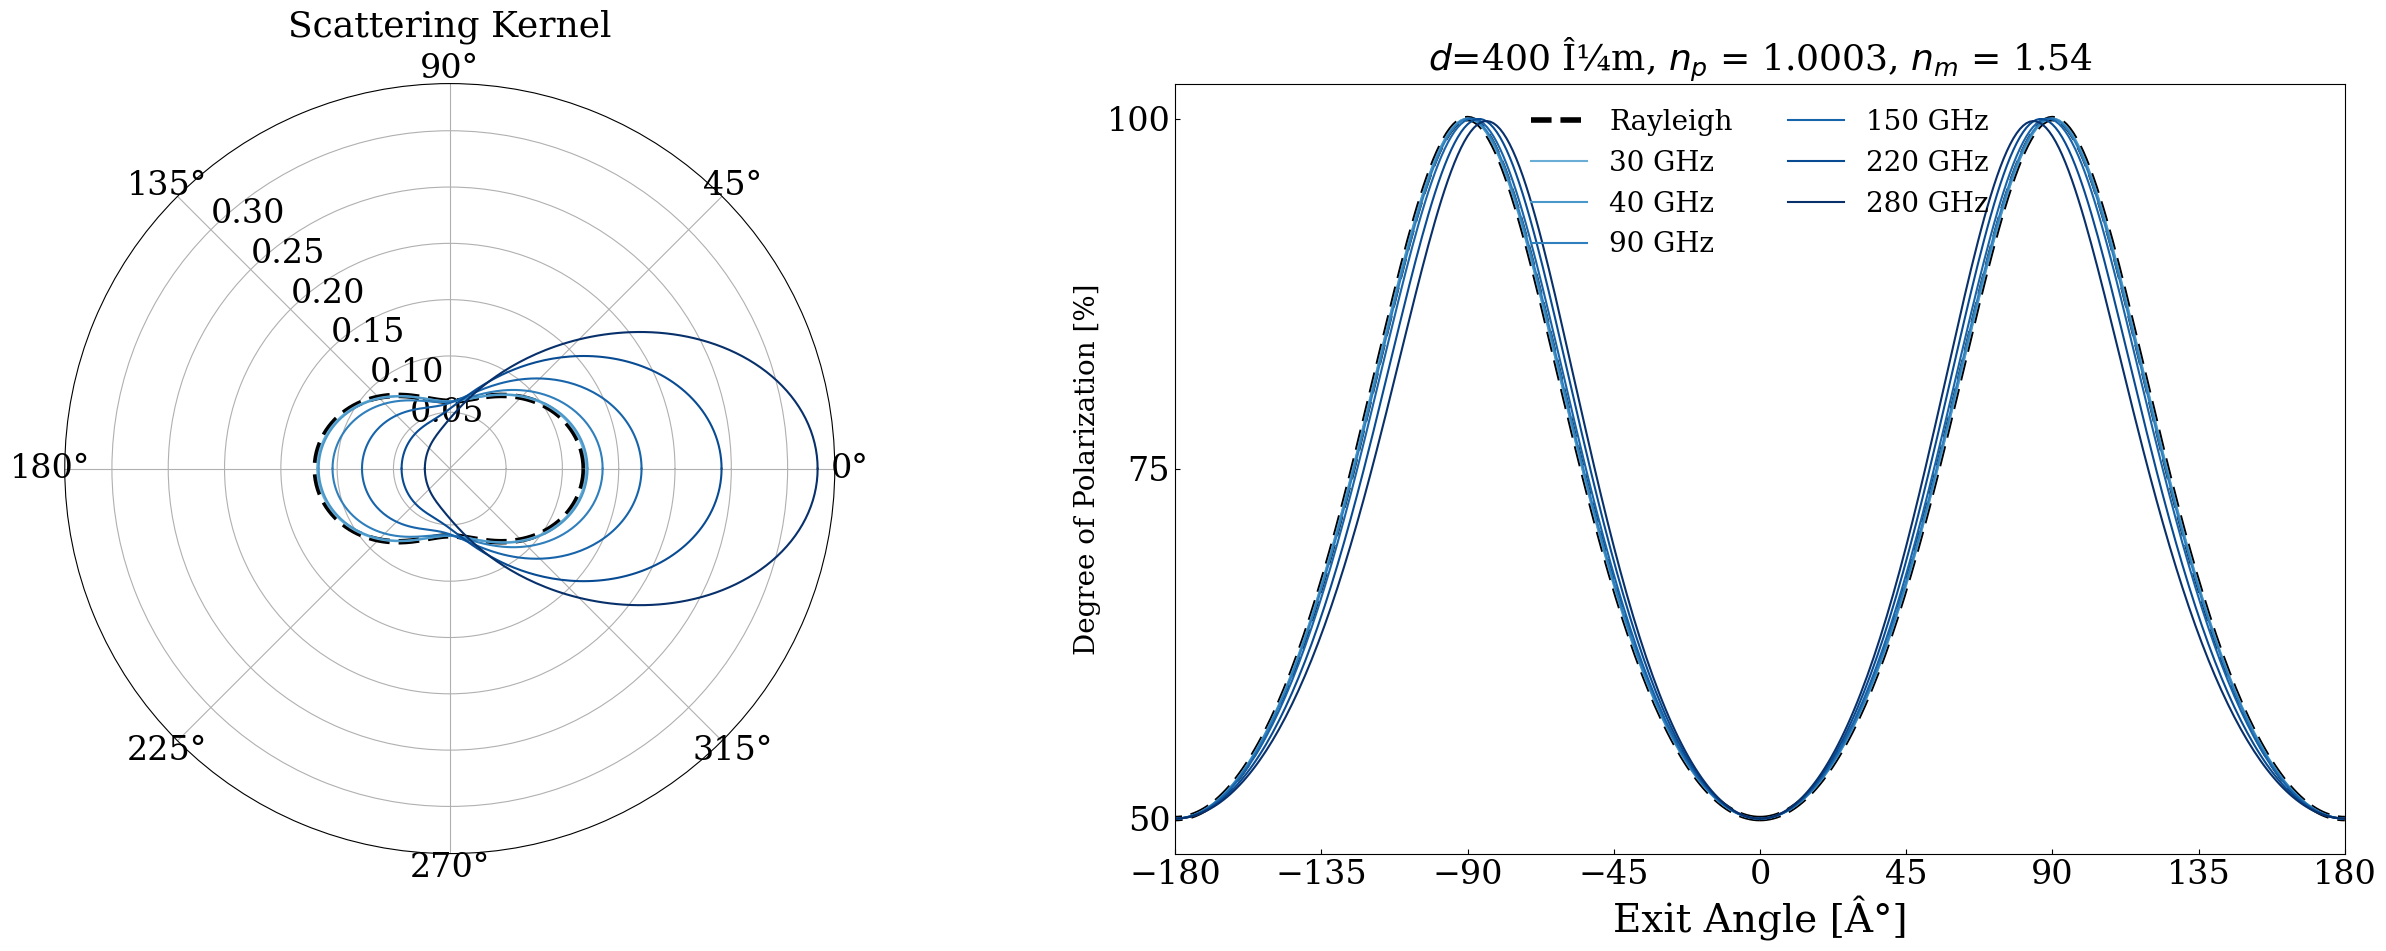

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Convert theta from degrees to radians for polar plotting

theta_rad = np.deg2rad(theta)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(32,10), gridspec_kw={'width_ratios':[1,1]})

# Make ax0 a polar plot
fig.delaxes(ax0)  # remove the original ax0
ax0 = fig.add_subplot(1, 2, 1, projection='polar')

# Plot Rayleigh curve
ax0.plot(theta_rad, I_ray, label='Rayleigh', color='k', ls='--', lw=4)
ax0.plot(-theta_rad, I_ray, color='k', ls='--', lw=4)

# Plot data curves
for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    I = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax0.plot(theta_rad, I, label=f"{f} GHz", color=colors1[i])
    ax0.plot(-theta_rad, I, color=colors1[i])

# Polar plot formatting
ax0.set_theta_zero_location("E")  # 0Â° at top
ax0.set_theta_direction(1)       # clockwise
ax0.set_rlabel_position(135)      # move radial labels away from plotted lines
ax0.set_title('Scattering Kernel', fontsize=26, y=1.05)

# Right-hand side plot remains Cartesian
ax1.plot(theta, 100/(1+np.cos(theta/180*np.pi)**2), label='Rayleigh', color='k', ls='--', lw=4)
ax1.plot(-theta, 100/(1+np.cos(theta/180*np.pi)**2), color='k', ls='--', lw=4)

for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    Iper = row["Iper"]
    Ipar = row["Ipar"]
    ax1.plot(theta, 100*Iper/(Iper+Ipar), label=f"{f} GHz", color=colors1[i])
    ax1.plot(-theta, 100*Iper/(Iper+Ipar), color=colors1[i])

ax1.set_ylabel('Degree of Polarization [%]', fontsize=20)
ax1.set_xlabel("Exit Angle [Â°]")
ax1.set_yticks([50, 75, 100])
ax1.legend(loc='upper center', ncol=2, frameon=False)
ax1.set_xlim(-180, 180)
ax1.set_xticks([-180, -135, -90, -45, 0, 45, 90, 135, 180])

ax1.set_title(r"$d$=400 Î¼m, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26)
plt.subplots_adjust(wspace=0.12)
plt.show()


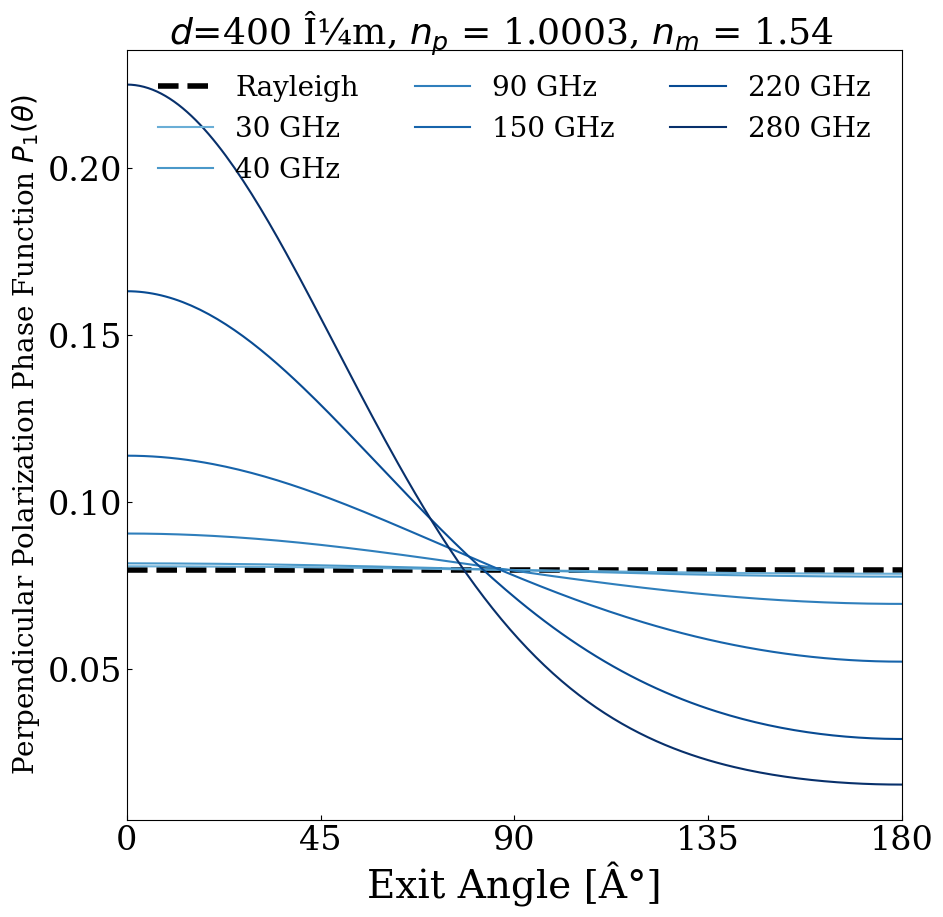

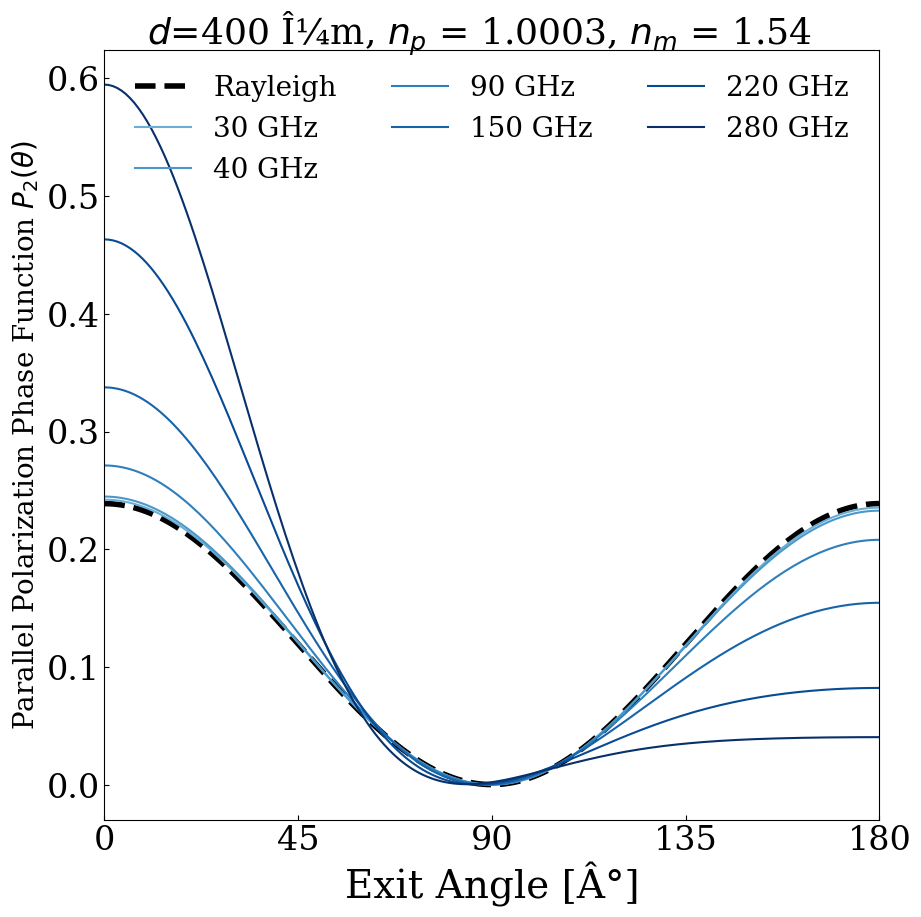

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(10,10), sharex=True)

ax.axhline(1/(4*np.pi), label='Rayleigh', color='k', ls='--', lw=4)

for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    I = row["I"]
    Iper_norm = row["Iper_norm"]

    ax.plot(theta, Iper_norm, label=f"{f} GHz", color=colors1[i])

ax.legend(loc='upper center', ncol=3, frameon=False)
ax.set_ylabel(r'Perpendicular Polarization Phase Function $P_1(\theta)$', fontsize=20)
plt.xlabel("Exit Angle [Â°]")
plt.xlim(0, 180)
plt.xticks([0, 45, 90, 135, 180])
# ax.set_yticks([50, 75, 100])
plt.suptitle(r"$d$=400 Î¼m, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=3)

plt.subplots_adjust(hspace=0.05)
# plt.yscale('log')
plt.gcf().set_facecolor('none')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10,10), sharex=True)

ax.plot(theta, (3/4/np.pi)*np.cos(theta / 180 * np.pi)**2, label='Rayleigh', color='k', ls='--', lw=4)

for i, (freq, row) in enumerate(df.iterrows()):
    f = row.name
    I = row["I"]
    Ipar_norm = row["Ipar_norm"]

    ax.plot(theta, Ipar_norm, label=f"{f} GHz", color=colors1[i])

ax.legend(loc='upper center', ncol=3, frameon=False)
ax.set_ylabel(r'Parallel Polarization Phase Function $P_2(\theta)$', fontsize=20)
plt.xlabel("Exit Angle [Â°]")
plt.xlim(0, 180)
plt.xticks([0, 45, 90, 135, 180])
# ax.set_yticks([50, 75, 100])
plt.suptitle(r"$d$=400 Î¼m, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=3)

plt.subplots_adjust(hspace=0.05)
# plt.yscale('log')
plt.gcf().set_facecolor('none')
plt.show()

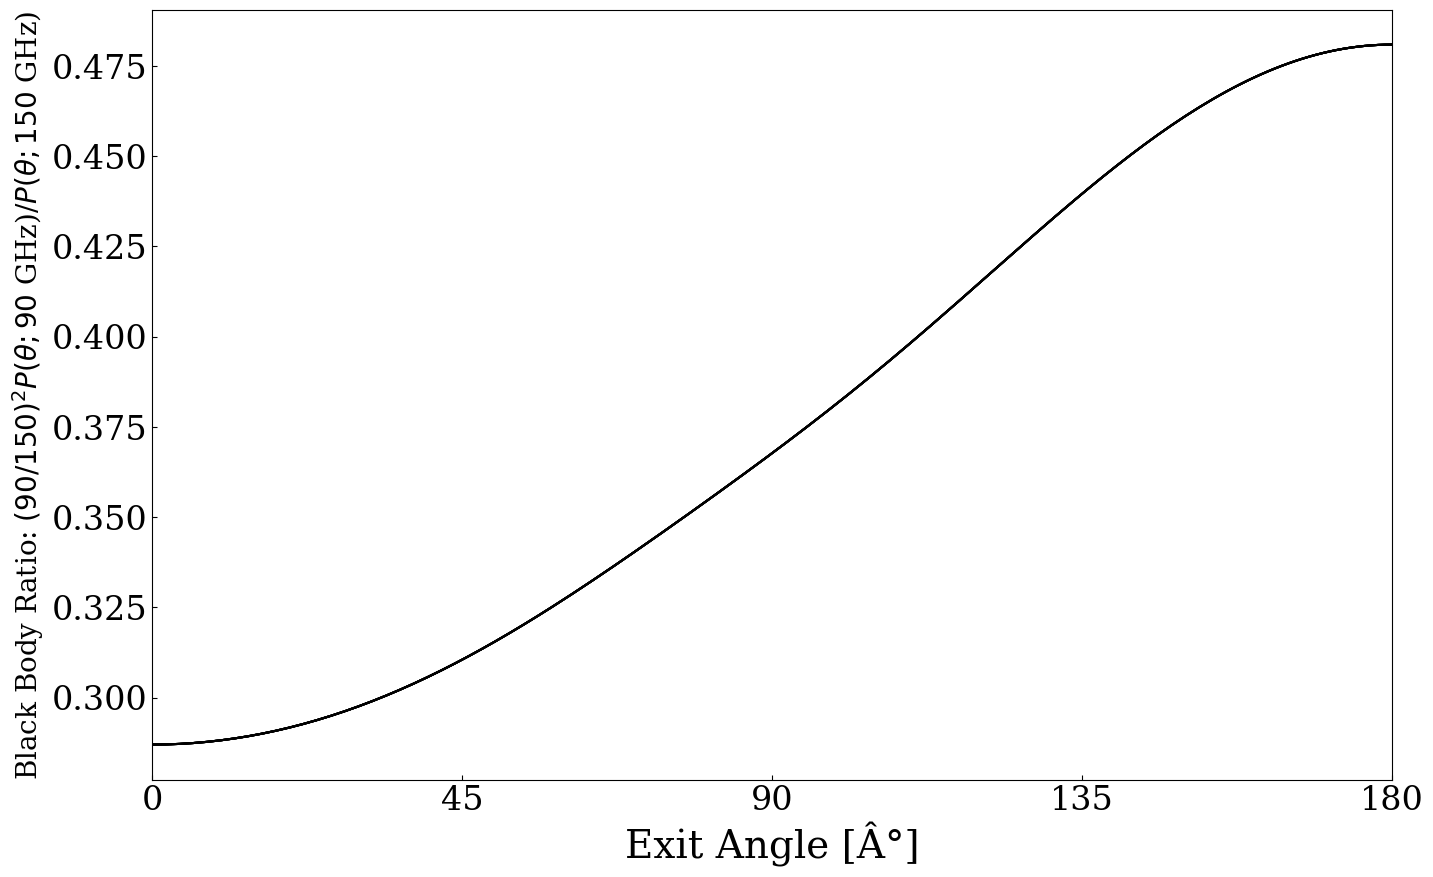

In [124]:
fig, ax = plt.subplots(figsize=(16,10), sharex=True)

for i, (freq, row) in enumerate(df.iterrows()):
    plt.plot(theta, 9/25*I_90/I_150, color='k')
    # ax0.scatter(theta_site, I_site, s=40)
    # ax1.plot(theta, Ipar, label='Parallel' if i==0 else None, color=colors1[i])

    # plt.text(0, 0, f"Average Angle\nUnpolarized: {Iunp_avg:.2f}\nParallel: {Ipar_avg:.2f}\nPerpendicular: {Iper_avg:.2f}", fontsize=32, ha='center')

plt.ylabel(r'Black Body Ratio: $(90/150)^2 P(\theta; 90$ GHz)/$P(\theta; 150$ GHz)', fontsize=20)
plt.xlabel("Exit Angle [Â°]")
plt.xlim(0, 180)
plt.xticks([0, 45, 90, 135, 180])

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=3)

plt.subplots_adjust(hspace=0.05)
# plt.yscale('log')
plt.show()

# Phase over Frequency

In [125]:
# Frequencies and wavelengths

theta = np.linspace(0, 180, 181)
mu = np.cos(theta / 180 * np.pi)

freq = np.arange(10, 2001, 1)  # GHz
lamb = GHz_to_lamb(freq * u.GHz).to(u.um).value  # wavelength [Âµm]

# Angles
mus = np.cos(np.deg2rad(theta))

# Particle size (scalar)
d_um = float(d.to(u.um).value)

n_f = len(freq)
n_ang = len(mu)

# Preallocate arrays: shape (n_freq, n_angles)
Ipar = np.empty((n_f, n_ang))
Iper = np.empty((n_f, n_ang))
I    = np.empty((n_f, n_ang))

# Loop over frequencies; compute all angles at once
for i, lam_um in enumerate(lamb):
    Ipar[i, :], Iper[i, :] = mie.intensities(
        n_p, d_um, lam_um, mu, n_env=n_m
    )

    I[i, :] = 0.5 * (Ipar[i, :] + Iper[i, :])

    norm_par = -2 * np.pi * np.trapezoid(Ipar[i, :], mu)
    norm_per = -2 * np.pi * np.trapezoid(Iper[i, :], mu)
    norm     = -2 * np.pi * np.trapezoid(I[i, :], mu)
    
    Ipar[i, :] /= norm_par
    Iper[i, :] /= norm_per
    I[i, :]    /= norm

results = []

df = pd.DataFrame({
    "theta_deg": theta,
    "mu": mu,
    "freq_GHz": [freq] * len(theta),
    "lambda_um": [lamb] * len(theta),
    "I": [I[:, j] for j in range(len(theta))],
    "Ipar": [Ipar[:, j] for j in range(len(theta))],
    "Iper": [Iper[:, j] for j in range(len(theta))],
}).set_index("theta_deg")



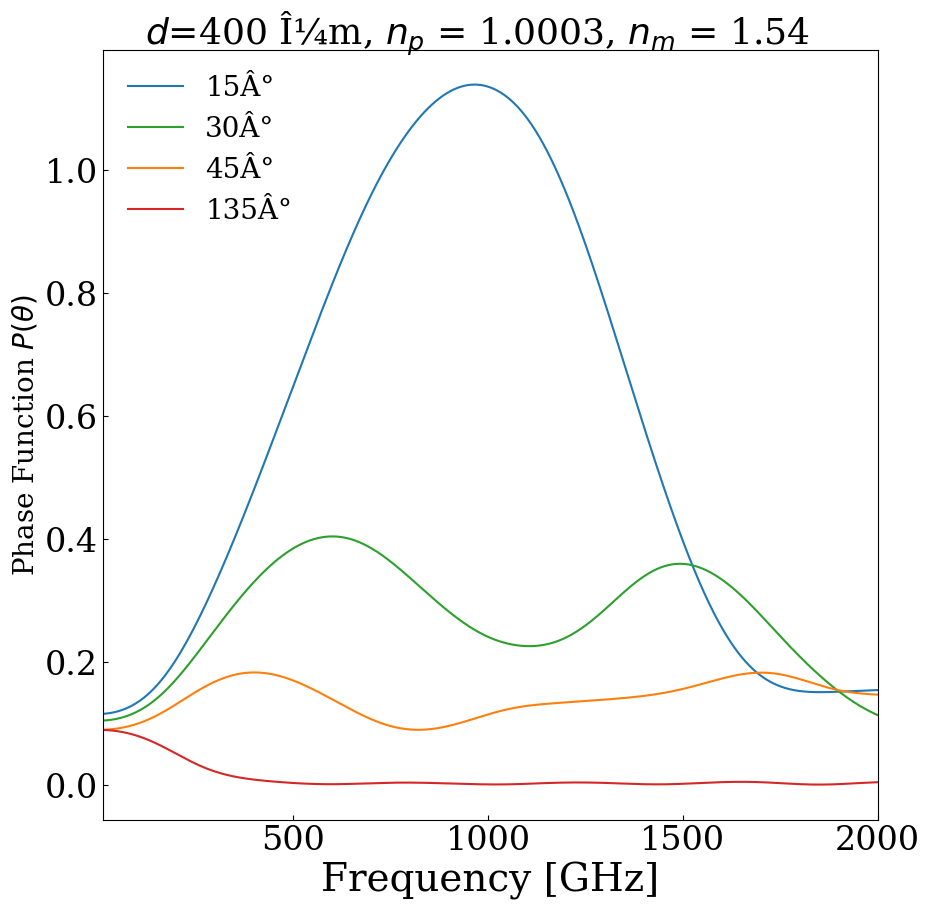

In [126]:
theta_meas = np.array([15, 30, 45, 135])  # degrees
colors = ['C0', 'C2', 'C1', 'C3']

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for i, theta_ in enumerate(theta_meas):
    row  = df.loc[theta_]       # select the row for this theta
    mu   = row["mu"]
    I    = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax.plot(freq, I, label=f"{theta_}Â°", color=colors[i])

# ax.set_ylim(ymin=0)
ax.set_xlim(10, 2000)
ax.legend(loc='upper left', frameon=False)
ax.set_ylabel(r'Phase Function $P(\theta)$', fontsize=20)
ax.set_xlabel("Frequency [GHz]")
plt.suptitle(r"$d$=400 Î¼m, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)
plt.gcf().set_facecolor('white')
plt.show()

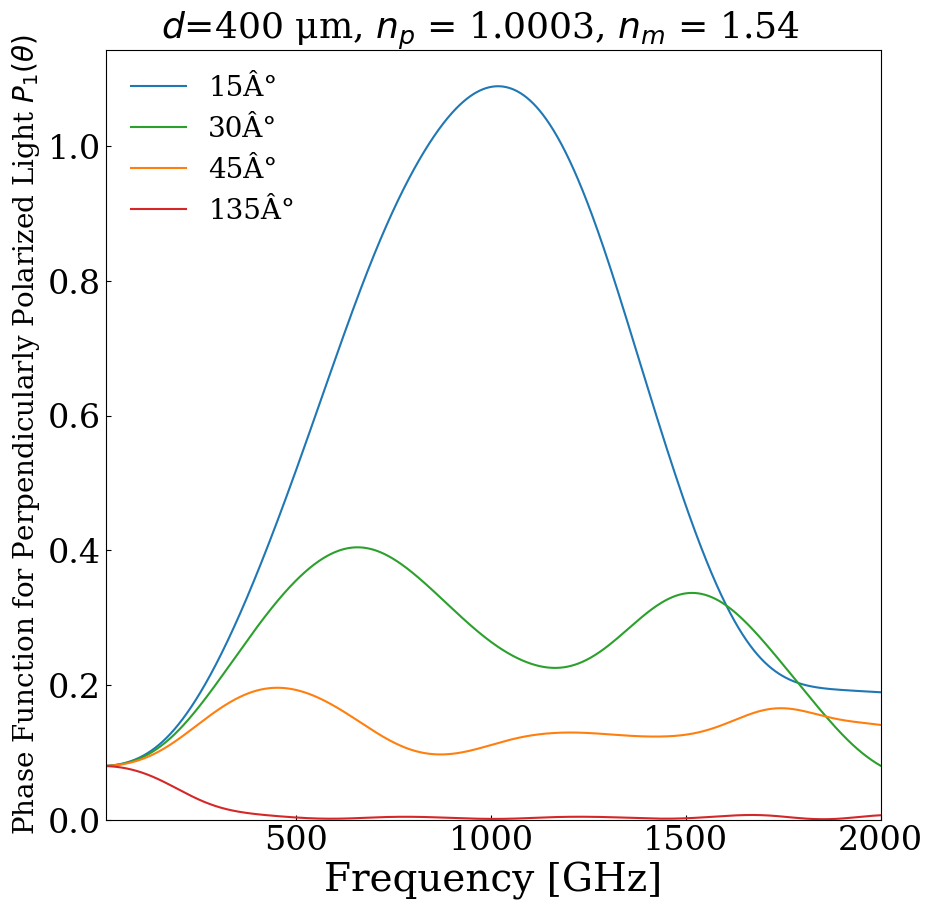

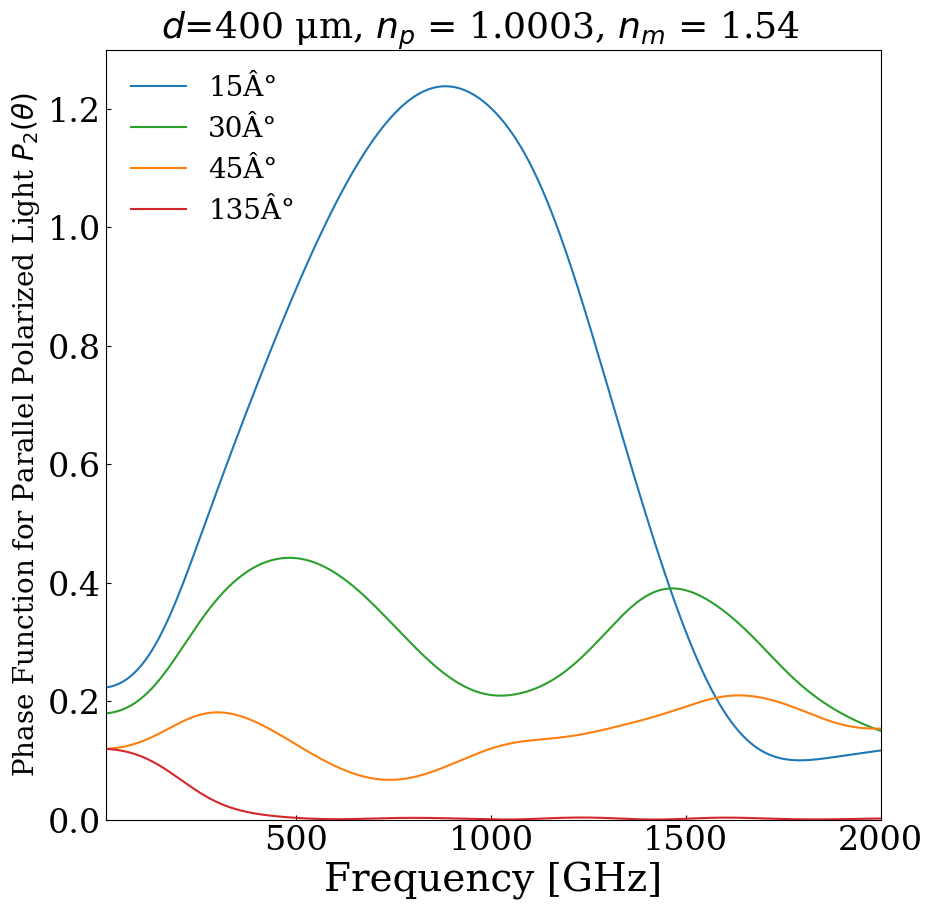

In [127]:
theta_meas = np.array([15, 30, 45, 135])  # degrees

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for i, theta_ in enumerate(theta_meas):
    row  = df.loc[theta_]       # select the row for this theta
    mu   = row["mu"]
    I    = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax.plot(freq, Iper, label=f"{theta_}Â°", color=colors[i])

ax.set_ylim(ymin=0)
ax.set_xlim(10, 2000)
ax.legend(loc='upper left', frameon=False)
ax.set_ylabel(r'Phase Function for Perpendicularly Polarized Light $P_1(\theta)$', fontsize=20)
ax.set_xlabel("Frequency [GHz]")
plt.suptitle(r"$d$=400 μm, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)
plt.gcf().set_facecolor('white')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for i, theta_ in enumerate(theta_meas):
    row  = df.loc[theta_]       # select the row for this theta
    mu   = row["mu"]
    I    = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax.plot(freq, Ipar, label=f"{theta_}Â°", color=colors[i])

ax.set_ylim(ymin=0)
ax.set_xlim(10, 2000)
ax.legend(loc='upper left', frameon=False)
ax.set_ylabel(r'Phase Function for Parallel Polarized Light $P_2(\theta)$', fontsize=20)
ax.set_xlabel("Frequency [GHz]")
plt.suptitle(r"$d$=400 μm, $n_p$ = 1.0003, $n_m$ = 1.54", fontsize=26, y=0.92)
plt.gcf().set_facecolor('white')
plt.show()

In [128]:
theta_full = df.index.to_numpy()        # all angles (-180..180)
freq       = df["freq_GHz"].iloc[0]     # 1D array of freq

# Rebuild 2D arrays: (n_freq, n_theta)
Ipar_2d = np.stack(df["Ipar"].to_numpy(), axis=0).T
Iper_2d = np.stack(df["Iper"].to_numpy(), axis=0).T
I_unpol_2d = 0.5 * (Ipar_2d + Iper_2d)

# Restrict to 0â€“180Â°
mask = (theta_full >= 0) & (theta_full <= 180)
theta_deg = theta_full[mask]
I_unpol = I_unpol_2d[:, mask]           # (n_freq, n_ang_pos)
Ipar_2d = Ipar_2d[:, mask]
Iper_2d = Iper_2d[:, mask]

In [129]:
# --- Thin-shell scattering kernel (Lange & Aragon 1990) ---
from scipy.special import spherical_jn, spherical_yn

def _psi(n, x):
    return x * spherical_jn(n, x)

def _psi_prime(n, x):
    return spherical_jn(n, x) + x * spherical_jn(n, x, derivative=True)

def _mie_ab_thin_shell(n, m, x, delta):
    psi_x  = _psi(n, x)
    psi_xp = _psi_prime(n, x)
    bn = -1j * delta * (m**2 - 1) * psi_x**2
    an = -1j * delta * (n*(n+1)*(m**2 - 1) / (m**2 * x**2) * psi_x**2
                        + (m**2 - 1) * psi_xp**2)
    return an, bn

def _pi_tau(n_max, theta_rad):
    ct = np.cos(theta_rad)
    pi_arr  = np.zeros((n_max, len(theta_rad)))
    tau_arr = np.zeros((n_max, len(theta_rad)))
    pi_pp, pi_p = np.zeros(len(theta_rad)), np.ones(len(theta_rad))
    for n in range(1, n_max + 1):
        tau_arr[n-1] = n * ct * pi_p - (n + 1) * pi_pp
        pi_arr[n-1]  = pi_p
        pi_next = ((2*n + 1) * ct * pi_p - (n + 1) * pi_pp) / n
        pi_pp, pi_p = pi_p, pi_next
    return pi_arr, tau_arr

def _phase_func(a_list, b_list, thetas_rad):
    pi_arr, tau_arr = _pi_tau(len(a_list), thetas_rad)
    S1 = np.zeros(len(thetas_rad), dtype=complex)
    S2 = np.zeros(len(thetas_rad), dtype=complex)
    for n, (an, bn) in enumerate(zip(a_list, b_list), start=1):
        fac = (2*n + 1) / (n * (n + 1))
        S1 += fac * (an * pi_arr[n-1] + bn * tau_arr[n-1])
        S2 += fac * (bn * pi_arr[n-1] + an * tau_arr[n-1])
    P = (np.abs(S1)**2 + np.abs(S2)**2) / 2.0
    norm = np.trapezoid(P * np.sin(thetas_rad), thetas_rad) * 2 * np.pi
    return P / norm  # normalized so int_4pi P dOmega = 1, matching cell 19

# Physical parameters
c_ts   = 30.0      # GHz·cm
n_m_ts = 1.0
n_p_ts = 1.54
m_ts   = n_p_ts / n_m_ts
d_ts   = 400e-4    # cm  (400 µm)
ell_ts = 2e-4      # cm  (2 µm)
N_mul  = 30

# Frequency and angle grids
freq_ts      = np.arange(150, 2001, 5, dtype=float)   # GHz
theta_deg_ts = np.linspace(0, 180, 181)
thetas_safe  = np.deg2rad(theta_deg_ts)
thetas_safe[0]  = 1e-6
thetas_safe[-1] = np.pi - 1e-6

I_unpol_shell = np.empty((len(freq_ts), len(theta_deg_ts)))

for _i, _f in enumerate(freq_ts):
    _x     = n_m_ts * np.pi * d_ts * _f / c_ts
    _delta = n_m_ts * np.pi * ell_ts * _f / c_ts
    _al, _bl = [], []
    for _n in range(1, N_mul + 1):
        _an, _bn = _mie_ab_thin_shell(_n, m_ts, _x, _delta)
        _al.append(_an); _bl.append(_bn)
    I_unpol_shell[_i, :] = _phase_func(_al, _bl, thetas_safe)

print(f"Thin-shell kernel computed: {I_unpol_shell.shape} (freq x angle)")


Thin-shell kernel computed: (371, 181) (freq x angle)


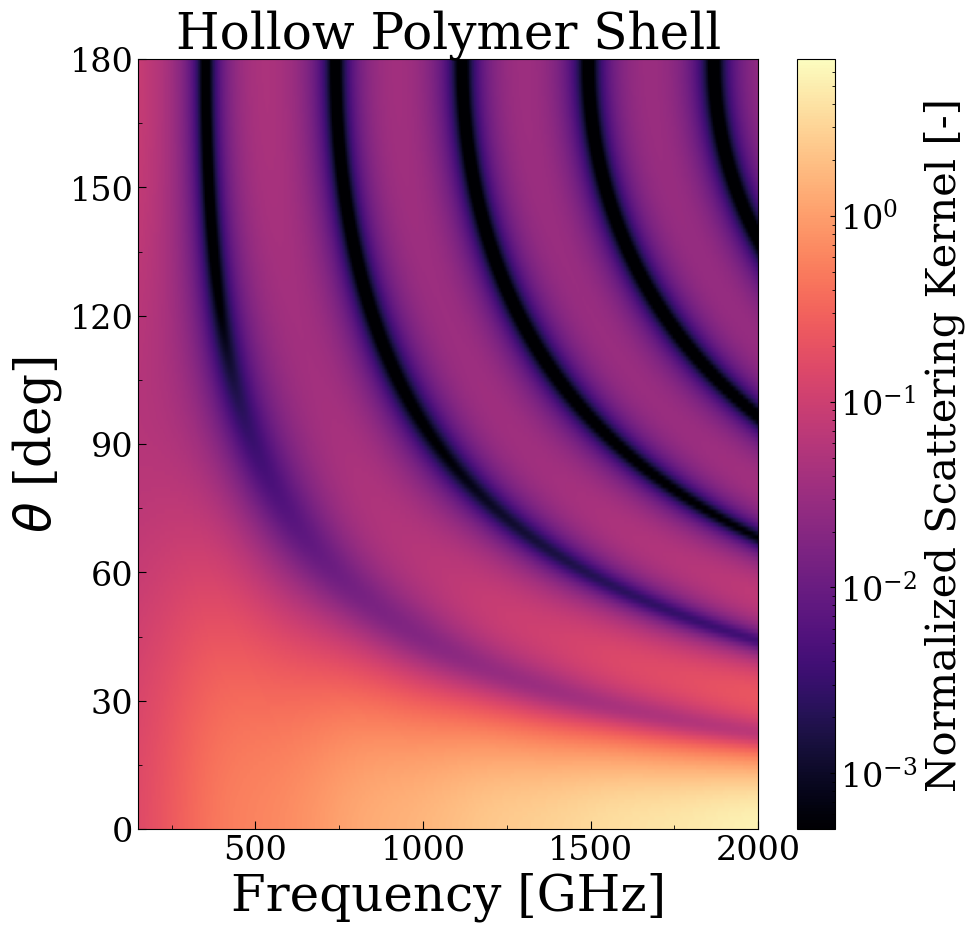

In [130]:
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(10, 10))

# Clip at 1e-2 to avoid the deep Mie nulls (~1e-8) compressing the colormap
pcm = ax.imshow(I_unpol_shell.T, origin="lower", aspect="auto",
                norm=LogNorm(vmin=5e-4, vmax=7),
                extent=[freq_ts.min(), freq_ts.max(),
                        theta_deg_ts.min(), theta_deg_ts.max()],
                cmap='magma')

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"Normalized Scattering Kernel [-]", fontsize=30)

ax.set_xlabel("Frequency [GHz]", fontsize=36)
ax.set_ylabel(r'$\theta$ [deg]', fontsize=36)
ax.set_ylim(0, 180)
ax.xaxis.set_major_locator(mticker.MultipleLocator(500))
ax.yaxis.set_major_locator(mticker.MultipleLocator(30))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(250))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(15))
ax.tick_params(axis='both', which='major', length=6)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_title('Hollow Polymer Shell', fontsize=36)

plt.savefig("hollow_polymer_shell.pdf", bbox_inches='tight', format='pdf')
plt.show()


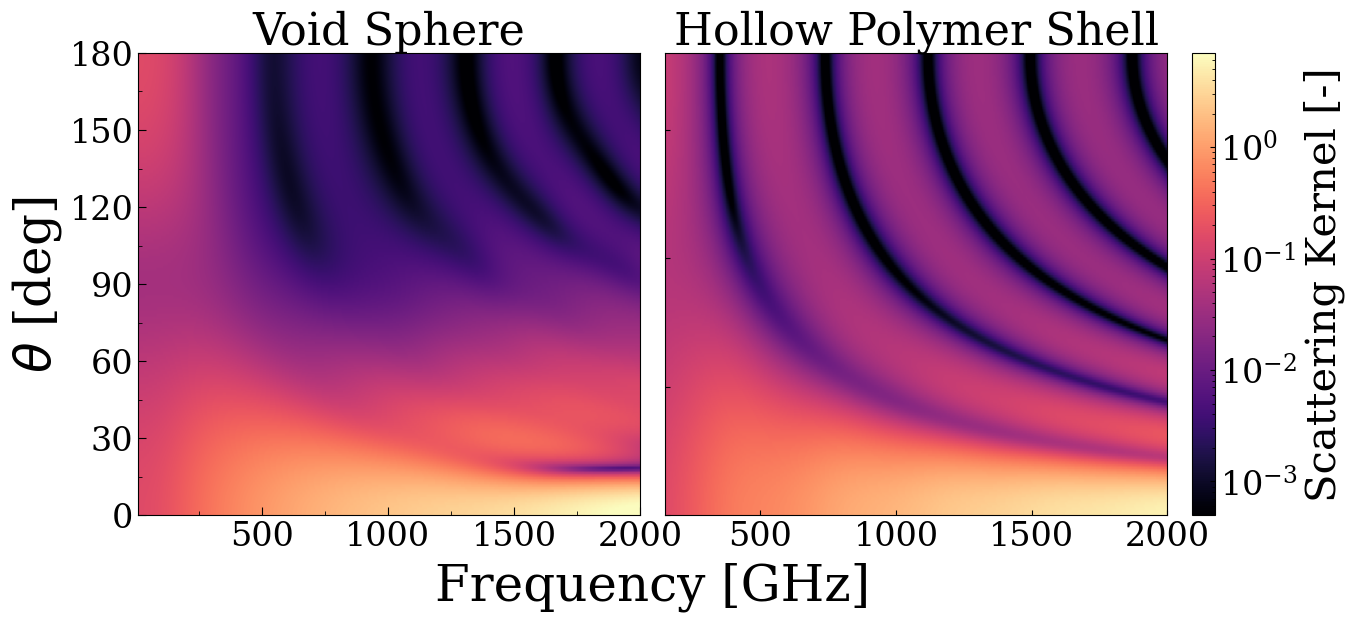

In [131]:
from matplotlib.colors import LogNorm   # log color scale helps a lot
import matplotlib.ticker as mticker
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'wspace': 0.05})

norm = LogNorm(vmin=5e-4, vmax=7)
pcm = ax1.imshow(I_unpol.T, origin="lower", aspect="auto", norm=norm,
                 extent=[freq.min(), freq.max(), theta_deg.min(), theta_deg.max()], cmap='magma')
pcm = ax2.imshow(I_unpol_shell.T, origin="lower", aspect="auto", norm=norm,
                 extent=[freq_ts.min(), freq_ts.max(), theta_deg_ts.min(), theta_deg_ts.max()], cmap='magma')

cbar = fig.colorbar(pcm, ax=[ax1, ax2], pad=0.02)
cbar.set_label(r"Scattering Kernel [-]", fontsize=30)

fig.canvas.draw()
x_center = (ax1.get_position().x0 + ax2.get_position().x1) / 2
fig.supxlabel("Frequency [GHz]", fontsize=36, x=x_center, y=-0.05)

ax1.set_ylabel(r"$\theta$ [deg]", fontsize=36)
ax1.set_ylim(0, 180)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(500))
ax1.yaxis.set_major_locator(mticker.MultipleLocator(30))
ax1.xaxis.set_minor_locator(mticker.MultipleLocator(250))
ax1.yaxis.set_minor_locator(mticker.MultipleLocator(15))
ax2.yaxis.set_ticklabels([])
ax1.tick_params(axis='both', which='major', length=6)
ax1.tick_params(axis='both', which='minor', length=3)
ax1.set_title('Void Sphere', fontsize=32)
ax2.set_title('Hollow Polymer Shell', fontsize=32)

plt.savefig("scattering_kernels_sim.pdf", bbox_inches='tight', format='pdf')
plt.show()
